# Langgraph 실습

## State 기획 필요
- `message` :str :사용자 입력 메세지
- `symptoms` :list[str] :추출한 증상들
- `diagnosis`: dict :증상, 영양소들, 추천종합 이유
- `answer`: str :최종 진단


## Node
1. START - 사용자의 아픈 증상을 메세지 입력
2. 메세지를 기반으로 증상 추출 (LLM)
3. *증상별로 도움되는 영양소를 뽑아줌* (**LLM with Structured Output**) - Agent 아님. `llm.invoke`
    ```
    [
        {
            'symptom': '배 아픔', 
            'nutrients': ['프로바이오틱스', '식이섬유', '비타민 C'],
            'reason': '프로바이오틱스는 장내 유익균을 증가시켜 소화기 건강을 돕고, ...'
        },
        {
            'symptom': '눈 뻑뻑함',
            'nutrients': ['오메가-3 지방산', '비타민 A', '비타민 E'],
            'reason': '오메가-3 지방산은 눈의 건조함을 줄이고 눈물막의 질을 개선합니다.'
        },
        {
            'symptom': '목 근육 통증',
            'nutrients': ['마그네슘', '비타민 D', '단백질'],
            'reason': '마그네슘은 근육 이완에 도움을 주고, 비타민 D는 근육 기능을...'
        }
    ]
    ```
4. 증상 + 영양소 목록으로 최종 안내문 생성 (LLM)
5. END

In [39]:
from dotenv import load_dotenv

load_dotenv()

True

In [40]:
from typing import TypedDict

# Graph 를 관통할 State 정의
class HealthState(TypedDict):
    message: str
    symptoms: list[str]  # list: 내부 요소들의 타입 무관 / List: 내부 요소들의 타입이 동일해야 함
    diagnosis: dict
    answer: str

In [41]:
# Node 정의
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage, SystemMessage

llm = init_chat_model('openai:gpt-4.1-mini')

In [42]:
def analyze_symptom_node(state: HealthState):
    message = state['message']
    result = llm.invoke([
        SystemMessage('너는 사용자의 메세지에서 증상들을 추출해 주는 AI야.'),
        HumanMessage(message)
    ])  # 결과가 AIMessage 가 나옴

    # 내가 state에서 바꾸고 싶은 부분만 return 한다.
    return {'symptoms': result.content}


# 수작업 테스트
analyze_symptom_node({
    'message': '나 배가 아프고 눈이 뻑뻑해. 목 근육도 아파'
})

{'symptoms': '사용자님의 증상은 다음과 같습니다:\n- 배 아픔\n- 눈 뻑뻑함\n- 목 근육 통증'}

In [ ]:
from pydantic import BaseModel, Field

# Structured Output -> Tip: 내가 원하는 응답 데이터의 형태를 알려주면, AI가 아래 코드를 짜줌
# 1. 개별 증상/영양소 추천 항목 정의
class HealthItem(BaseModel):
    symptom: str = Field(description="증상")
    nutrients: list[str] = Field(description="추천하는 영양소 목록")
    reason: str = Field(description="각 영양소를 추천한 종합 소견")
    
# 2. 리스트 형태를 담을 래퍼(Wrapper) 모델 정의
class HealthRecommendationList(BaseModel):
    items: list[HealthItem] = Field(
        description="증상별 영양소 추천 목록 리스트"
    )

In [ ]:
def recommend_nutrients_node(state: HealthState):
    symptoms = state['symptoms']
    system_msg = ''''주어진 증상들을 보고, 적절히 각 증상별로
    1. 증상이름
    2. 해당 증상에 좋은 영양소들
    3. 추천 이유
    를 만들어줘
'''
    # 기존 LLM을 구조 출력용으로 업그레이드 (출력 스키마대로 나올 수 있도록)
    structured_llm = llm.with_structured_output(HealthRecommendationList)
    
    result = structured_llm.invoke([
        SystemMessage(system_msg),
        HumanMessage(f'증상들: {symptoms}')
    ])  # structured_llm 은 결과가 AIMessage 아님.
    
    return {'diagnosis': result.model_dump()}  # result.content가 아니라 result.model_dump()


# 수작업 테스트
result = recommend_nutrients_node({
    'message': '나 배가 아프고 눈이 뻑뻑해. 목 근육도 아파',
    'symptoms': '사용자께서 언급한 증상들은 다음과 같습니다:\n1. 배 아픔\n2. 눈 뻑뻑함\n3. 목 근육 통증'
})

In [45]:
result['diagnosis']

{'items': [{'symptom': '배 아픔',
   'nutrients': ['프로바이오틱스', '식이섬유', '비타민 C'],
   'reason': '프로바이오틱스는 장내 유익균을 증가시켜 소화기 건강을 돕고, 식이섬유는 장운동을 원활하게 하여 배 아픔 완화에 도움을 줍니다. 비타민 C는 면역력을 증진시켜 염증 완화에 기여합니다.'},
  {'symptom': '눈 뻑뻑함',
   'nutrients': ['오메가-3 지방산', '비타민 A', '비타민 E'],
   'reason': '오메가-3 지방산은 눈의 건조함을 줄이고 눈물막의 질을 개선합니다. 비타민 A는 눈 건강에 필수적이며, 비타민 E는 항산화 작용으로 눈을 보호합니다.'},
  {'symptom': '목 근육 통증',
   'nutrients': ['마그네슘', '비타민 D', '단백질'],
   'reason': '마그네슘은 근육 이완에 도움을 주고, 비타민 D는 근육 기능을 지원합니다. 단백질은 근육 회복과 강화에 필수적입니다.'}]}

In [46]:
[{'symptom': '복통, 눈의 건조감 및 목 근육 통증의 증상들',
   'nutrients': ['마그네슘', '오메가-3 지방산', '비타민 A', '비타민 E'],
   'reason': '배 아픔과 근육통에는 마그네슘이 근육 이완과 통증 완화에 도움을 주며, 눈 뻑뻑함은 비타민 A와 E가 눈 건강과 눈물막 유지에 중요합니다. 오메가-3 지방산은 염증 완화와 근육 건강에 기여하여 전반적인 증상 개선에 적합합니다.'}]

[{'symptom': '복통, 눈의 건조감 및 목 근육 통증의 증상들',
  'nutrients': ['마그네슘', '오메가-3 지방산', '비타민 A', '비타민 E'],
  'reason': '배 아픔과 근육통에는 마그네슘이 근육 이완과 통증 완화에 도움을 주며, 눈 뻑뻑함은 비타민 A와 E가 눈 건강과 눈물막 유지에 중요합니다. 오메가-3 지방산은 염증 완화와 근육 건강에 기여하여 전반적인 증상 개선에 적합합니다.'}]

In [47]:
def generate_answer_node(state: HealthState):
    user_prompt = f'''사용자의 증상, 분석, 영양소등을 기록해 둔 자료
사용자 입력: {state['message']}
분석한 증상: {state['symptoms']}
진단: {state['diagnosis']}
'''

    result = llm.invoke([
        SystemMessage('넌 종합 해주는 AI야. 주어진 정보들을 모아서 깔끔한 답변을 만들어줘'),
        HumanMessage(user_prompt)
    ])
    return {'answer': result.content}


# 수작업 테스트
generate_answer_node({
    'message': '나 배가 아프고 눈이 뻑뻑해. 목 근육도 아파',
    'symptoms': '사용자께서 언급한 증상들은 다음과 같습니다:\n1. 배 아픔\n2. 눈 뻑뻑함\n3. 목 근육 통증',
    'diagnosis': '1. 증상 요약: 복통, 안구 건조감 및 자세 불량으로 인한 목 근육 통증이 동반된 증상군.\n\n2. 추천 영양소: 마그네슘, 비타민 A, 오메가-3 지방산\n\n3. 추천 이유: \n- 마그네슘은 근육 이완과 신경 안정에 도움을 주어 목 근육 통증 완화에 효과적입니다.\n- 비타민 A는 눈 건강과 눈 점막 유지에 중요해 눈 뻑뻑함 개선에 기여합니다.\n- 오메가-3 지방산은 염증 감소와 점막 건강 증진에 도움을 주어 복통과 눈 건조 증상 완화에 도움될 수 있습니다.'
})

{'answer': '사용자께서 경험하시는 배 아픔, 눈 뻑뻣함, 그리고 목 근육 통증은 복통, 안구 건조 및 자세 불량으로 인한 근육 문제로 요약할 수 있습니다. 이를 완화하기 위해 마그네슘, 비타민 A, 오메가-3 지방산 섭취를 권장드립니다. 마그네슘은 근육 이완과 신경 안정에 도움을 주어 목 근육 통증 완화에 효과적이며, 비타민 A는 눈 건강과 점막 유지에 중요해 눈 뻑뻣함 개선에 기여합니다. 또한, 오메가-3 지방산은 염증 감소와 점막 건강 증진에 도움을 주어 복통과 눈 건조 증상 완화에 도움이 됩니다. 적절한 영양소 섭취와 함께 증상이 지속되면 전문의 상담을 받으시길 권합니다.'}

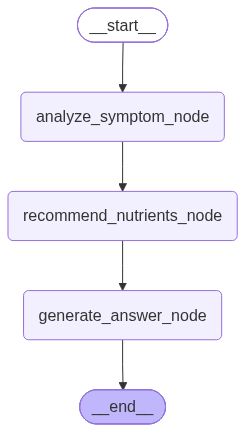

In [48]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(HealthState)

# 등록할때 ('등록할이름', 함수이름) 이 완전 같다면, 함수 이름만 적어도 됨.
builder.add_node('analyze_symptom_node', analyze_symptom_node)
builder.add_node(recommend_nutrients_node)
builder.add_node(generate_answer_node)

# 조립 -> Edge 연결
builder.add_edge(START, 'analyze_symptom_node')
builder.add_edge('analyze_symptom_node', 'recommend_nutrients_node')
builder.add_edge('recommend_nutrients_node', 'generate_answer_node')
builder.add_edge('generate_answer_node', END)

graph = builder.compile()
graph

In [49]:
graph_result = graph.invoke({
    'message': '나 머리가 아프고 눈이 뻑뻑해. 허리도 좀 아파'
})

print(graph_result['answer'])

사용자께서 겪고 계신 머리 아픔, 눈 뻑뻑함, 허리 통증 증상에 대해 분석한 결과, 각 증상에 도움이 되는 주요 영양소와 그 이유를 정리해드리겠습니다.

1. 머리 아픔
- 권장 영양소: 마그네슘, 오메가-3 지방산, 비타민 B2
- 이유: 마그네슘은 혈관 이완을 도와 두통 완화에 효과적이며, 오메가-3 지방산은 뇌 기능 개선과 염증 감소에 도움을 줍니다. 비타민 B2는 편두통 빈도를 줄이는 데도 도움이 됩니다.

2. 눈 뻑뻑함
- 권장 영양소: 오메가-3 지방산, 비타민 A, 비타민 E
- 이유: 오메가-3 지방산은 눈물막 형성을 개선하여 눈의 건조함을 줄여주고, 비타민 A는 시력 유지와 눈 건강에 필수적입니다. 비타민 E는 항산화 작용으로 눈 조직을 보호합니다.

3. 허리 통증
- 권장 영양소: 칼슘, 비타민 D, 칼륨
- 이유: 칼슘과 비타민 D는 뼈 건강을 강화하여 허리 통증 완화에 도움을 주며, 칼륨은 근육 기능을 개선하여 근육 경련과 통증을 줄여줍니다.

종합적으로, 위 증상 완화를 위해 마그네슘, 오메가-3 지방산, 비타민 B2, 비타민 A, 비타민 E, 칼슘, 비타민 D, 칼륨 섭취를 고려하는 것이 좋겠습니다. 균형 잡힌 식단과 함께 필요시 영양 보충제를 활용하시고, 지속되는 통증이나 증상 악화 시에는 전문 의료진의 진료를 받으시길 권해드립니다.
